In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
from loguru import logger

sys.path.insert(0, os.path.abspath("../../.."))

from spatial_nav.CAN_IMP.QAN3D import Torus3DQAN
from spatial_nav.CAN_IMP.torch_backend import TorchBackend
from spatial_nav.CAN_IMP.visualize3D import visualize_trajectory_projections, wrapped_angle_diff

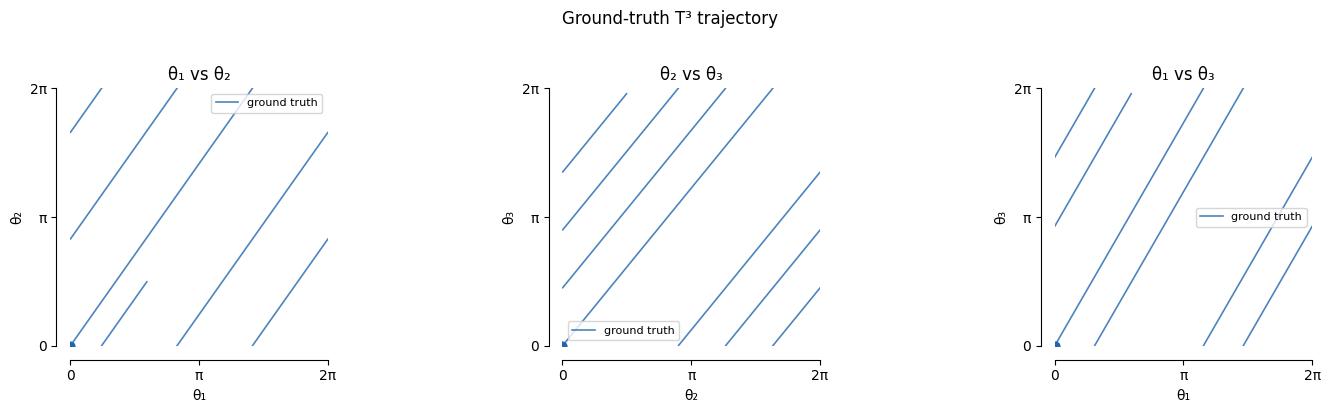

In [2]:
qan_sim = Torus3DQAN(
    spacing=0.3,
    alpha=1.5,
    sigma=1.4,
    b=0.83,
    velocity_gains=65,
)

trajectory = qan_sim.make_trajectory(n_steps=5000)

fig, _ = visualize_trajectory_projections(
    trajectory,
    title="Ground-truth T³ trajectory"
)
plt.show()

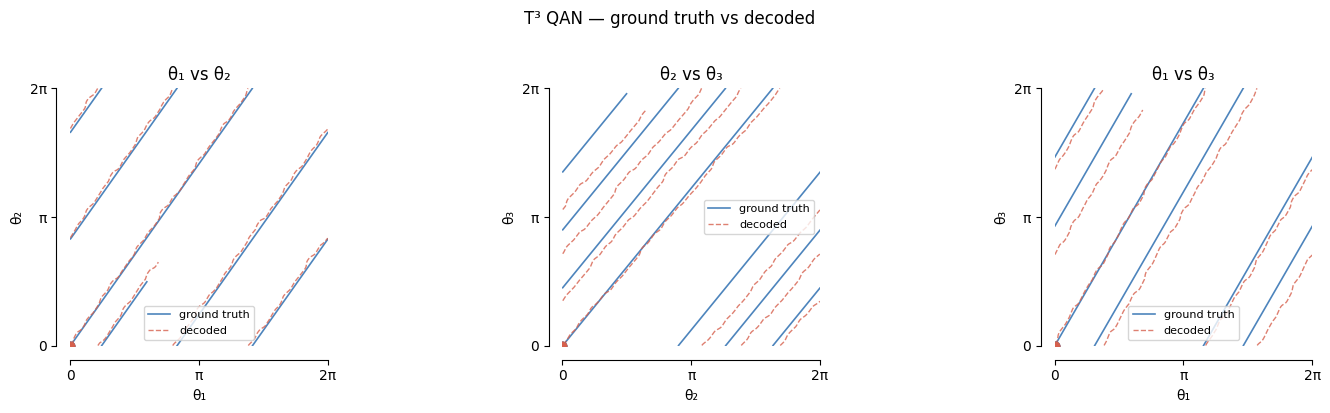

In [3]:
backend = TorchBackend(qan=qan_sim)

decoded = backend.simulate(trajectory)

fig, _ = visualize_trajectory_projections(
    trajectory,
    decoded,
    title="T³ QAN — ground truth vs decoded"
)
plt.show()

In [4]:
# Total trajectory length (sum of per-step displacements)
steps = np.linalg.norm(wrapped_angle_diff(trajectory[1:], trajectory[:-1]), axis=1)
traj_length = np.cumsum(steps)

# Normalized error = cumulative_error / distance_traveled
err = np.linalg.norm(wrapped_angle_diff(decoded, trajectory), axis=1)
normalized_err = err[1:] / (traj_length + 1e-9)

print(f"Normalized error (MADE metric): {np.mean(normalized_err):.4f}")

Normalized error (MADE metric): 0.0296
